# Chalconatronite Classification — Pipeline complet avec patches annotés
### EfficientNet-B0 · Approche A : extraction de patches + fusion dataset original

**Ce notebook :**
1. Vérifie tes annotations YOLO
2. Extrait les patches de chalconatronite (positifs) + patches cuivre propre (négatifs)
3. Fusionne avec les 500+ images originales
4. Entraîne EfficientNet-B0 sur le dataset enrichi
5. Évalue + affiche les erreurs + test sur image externe

In [1]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from PIL import Image, ImageDraw
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import classification_report, confusion_matrix

print("Imports OK")
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())

Imports OK
PyTorch : 2.5.1+cu121
CUDA    : True


In [2]:
# =============================================================
# CONFIGURATION  —  seul endroit à modifier
# =============================================================

# Structure attendue :
# tr_img/
# ├── chalcona_complet.ipynb   ← ce notebook
# ├── images/                  ← images annotées avec LabelImg
# ├── labels/                  ← fichiers .txt YOLO correspondants
# └── dataset/
#     ├── with_chalconatronite/    ← toutes les images positives (500+)
#     └── without_chalconatronite/ ← toutes les images négatives (cuivre propre)

# Dossiers sources
IMAGE_DIR_ANNOT  = "images/"                              # images annotées avec LabelImg
LABEL_DIR        = "labels/"                              # fichiers .txt YOLO correspondants
ORIGINAL_POS_DIR = "dataset/with_chalconatronite/"        # 500+ images positives originales
ORIGINAL_NEG_DIR = "dataset/without_chalconatronite/"     # images cuivre propre (SEULE source de négatifs)

# Dossiers de sortie
PATCHES_RAW_DIR  = "patches_raw/"
TRAIN_DIR        = "dataset_split/train"
VAL_DIR          = "dataset_split/val"
TEST_DIR         = "dataset_split/test"

# Paramètres extraction
PATCH_SIZE     = 224    # taille des patches extraits
NEG_PER_BOX    = 0      # 0 = aucun patch négatif tiré depuis les images annotées
                         # → les négatifs viennent UNIQUEMENT de dataset/without_chalconatronite/
PATCH_MARGIN   = 0.20   # marge autour de la boîte annotée (20%)

# Paramètres split
VAL_RATIO      = 0.15
TEST_RATIO     = 0.10

# Paramètres entraînement
BATCH_SIZE     = 32
NUM_EPOCHS     = 15
LR             = 0.001
UNFREEZE_EPOCH = 5      # epoch à partir de laquelle on dégèle les features

CLASS_NAMES = ["with_chalconatronite", "without_chalconatronite"]

MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

Device : cuda


## 1 — Vérification des annotations YOLO

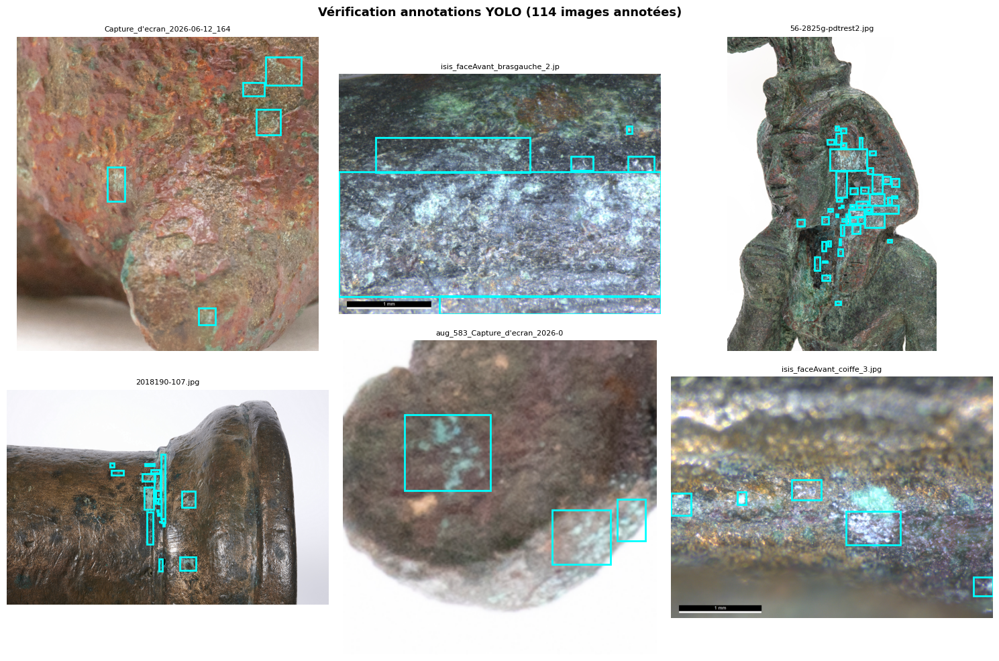

Total images annotées trouvées : 114


In [3]:
def show_annotations(image_dir, label_dir, n=6):
    """Affiche les boîtes YOLO sur les images pour vérifier les annotations."""
    files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.png'))]
    files = [f for f in files
             if os.path.exists(os.path.join(label_dir, f.rsplit('.', 1)[0] + '.txt'))]
    if not files:
        print("Aucune image annotée trouvée. Vérifiez IMAGE_DIR_ANNOT et LABEL_DIR.")
        return
    random.shuffle(files)
    n = min(n, len(files))
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = np.array(axes).flatten()
    fig.suptitle(f"Vérification annotations YOLO ({len(files)} images annotées)", fontsize=13, fontweight='bold')
    for ax, fname in zip(axes[:n], files[:n]):
        img = Image.open(os.path.join(image_dir, fname)).convert("RGB")
        W, H = img.size
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(fname[:30], fontsize=8)
        label_file = os.path.join(label_dir, fname.rsplit('.', 1)[0] + '.txt')
        with open(label_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = (cx - bw / 2) * W
                y1 = (cy - bh / 2) * H
                rect = mpatches.Rectangle(
                    (x1, y1), bw * W, bh * H,
                    linewidth=2, edgecolor='cyan', facecolor='none'
                )
                ax.add_patch(rect)
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    print(f"Total images annotées trouvées : {len(files)}")

show_annotations(IMAGE_DIR_ANNOT, LABEL_DIR)

## 2 — Extraction des patches annotés

In [4]:
def iou(box1, box2):
    """Intersection over Union entre deux boîtes (x1,y1,x2,y2)."""
    xi1 = max(box1[0], box2[0]); yi1 = max(box1[1], box2[1])
    xi2 = min(box1[2], box2[2]); yi2 = min(box1[3], box2[3])
    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    a1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    a2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    return inter / (a1 + a2 - inter + 1e-6)


def extract_patches(image_dir, label_dir, out_pos,
                    patch_size=224, margin=0.20):
    """
    Extrait UNIQUEMENT les patches POSITIFS depuis les images annotées.
    Les zones annotées sont découpées avec une marge (margin) autour de la boîte
    puis redimensionnées à patch_size×patch_size.

    ⚠ Aucun patch négatif n'est tiré depuis les images annotées.
    Les négatifs viennent exclusivement de dataset/without_chalconatronite/
    via copy_originals() à l'étape suivante.
    """
    os.makedirs(out_pos, exist_ok=True)

    files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.png'))]
    files = [f for f in files
             if os.path.exists(os.path.join(label_dir, f.rsplit('.', 1)[0] + '.txt'))]

    n_pos = 0

    for fname in files:
        img = Image.open(os.path.join(image_dir, fname)).convert("RGB")
        W, H = img.size
        stem = fname.rsplit('.', 1)[0]
        label_file = os.path.join(label_dir, stem + '.txt')

        with open(label_file) as f:
            boxes_norm = [
                list(map(float, l.strip().split()[1:5]))
                for l in f if len(l.strip().split()) >= 5
            ]

        # Conversion en pixels
        boxes_px = []
        for cx, cy, bw, bh in boxes_norm:
            x1 = max(0, int((cx - bw / 2) * W))
            y1 = max(0, int((cy - bh / 2) * H))
            x2 = min(W, int((cx + bw / 2) * W))
            y2 = min(H, int((cy + bh / 2) * H))
            boxes_px.append((x1, y1, x2, y2))

        # ── Patches POSITIFS uniquement ─────────────────────────────
        for i, (x1, y1, x2, y2) in enumerate(boxes_px):
            bw_px = x2 - x1; bh_px = y2 - y1
            mx = int(bw_px * margin); my = int(bh_px * margin)
            rx1 = max(0, x1 - mx); ry1 = max(0, y1 - my)
            rx2 = min(W, x2 + mx); ry2 = min(H, y2 + my)
            patch = img.crop((rx1, ry1, rx2, ry2)).resize(
                (patch_size, patch_size), Image.BILINEAR
            )
            patch.save(f"{out_pos}/{stem}_patch{i}.jpg")
            n_pos += 1

    print(f"Extraction patches positifs terminée : {n_pos} patches")
    print(f"  (depuis {len(files)} images annotées)")
    return n_pos


n_pos = extract_patches(
    image_dir  = IMAGE_DIR_ANNOT,
    label_dir  = LABEL_DIR,
    out_pos    = os.path.join(PATCHES_RAW_DIR, "with_chalconatronite"),
    patch_size = PATCH_SIZE,
    margin     = PATCH_MARGIN
)

Extraction patches positifs terminée : 1928 patches
  (depuis 114 images annotées)


## 3 — Fusion avec le dataset original

In [5]:
def copy_originals(src_dir, dst_dir, label):
    """
    Copie toutes les images d'un dossier source dans dst_dir.
    Préfixe 'orig_' pour éviter les collisions de noms avec les patches.
    """
    if not os.path.exists(src_dir):
        print(f"Dossier introuvable, ignoré : {src_dir}")
        return 0
    os.makedirs(dst_dir, exist_ok=True)
    count = 0
    for fname in os.listdir(src_dir):
        if fname.lower().endswith(('.jpg', '.png', '.jpeg', '.bmp')):
            src = os.path.join(src_dir, fname)
            dst = os.path.join(dst_dir, "orig_" + fname)
            shutil.copy(src, dst)
            count += 1
    print(f"  {label} : {count} images copiées → {dst_dir}")
    return count


print("Fusion du dataset :")
print()

# ── Positifs : patches annotés (déjà dans patches_raw) + images originales ──
print("POSITIFS :")
n_orig_pos = copy_originals(
    ORIGINAL_POS_DIR,
    os.path.join(PATCHES_RAW_DIR, "with_chalconatronite"),
    "Images originales with_chalconatronite"
)

# ── Négatifs : UNIQUEMENT depuis dataset/without_chalconatronite/ ────────────
# Aucun patch négatif n'est tiré depuis les images annotées (risque de chalco non annotée)
print()
print("NÉGATIFS (source unique = dataset/without_chalconatronite/) :")
n_orig_neg = copy_originals(
    ORIGINAL_NEG_DIR,
    os.path.join(PATCHES_RAW_DIR, "without_chalconatronite"),
    "Images originales without_chalconatronite"
)

# ── Bilan ─────────────────────────────────────────────────────────────────────
pos_dir   = os.path.join(PATCHES_RAW_DIR, "with_chalconatronite")
neg_dir   = os.path.join(PATCHES_RAW_DIR, "without_chalconatronite")
total_pos = len([f for f in os.listdir(pos_dir) if not f.startswith('.')])
total_neg = len([f for f in os.listdir(neg_dir) if not f.startswith('.')])

print()
print("=" * 55)
print(f"  BILAN patches_raw/")
print(f"  with_chalconatronite    : {total_pos} images")
print(f"    dont patches annotés  : {n_pos}")
print(f"    dont originaux        : {n_orig_pos}")
print(f"  without_chalconatronite : {total_neg} images")
print(f"    dont originaux        : {n_orig_neg}")
print(f"    dont patches annotés  : 0  ← garanti")
print("=" * 55)

Fusion du dataset :

POSITIFS :
  Images originales with_chalconatronite : 2300 images copiées → patches_raw/with_chalconatronite

NÉGATIFS (source unique = dataset/without_chalconatronite/) :
  Images originales without_chalconatronite : 1721 images copiées → patches_raw/without_chalconatronite

  BILAN patches_raw/
  with_chalconatronite    : 4228 images
    dont patches annotés  : 1928
    dont originaux        : 2300
  without_chalconatronite : 1721 images
    dont originaux        : 1721
    dont patches annotés  : 0  ← garanti


## 4 — Aperçu des patches extraits

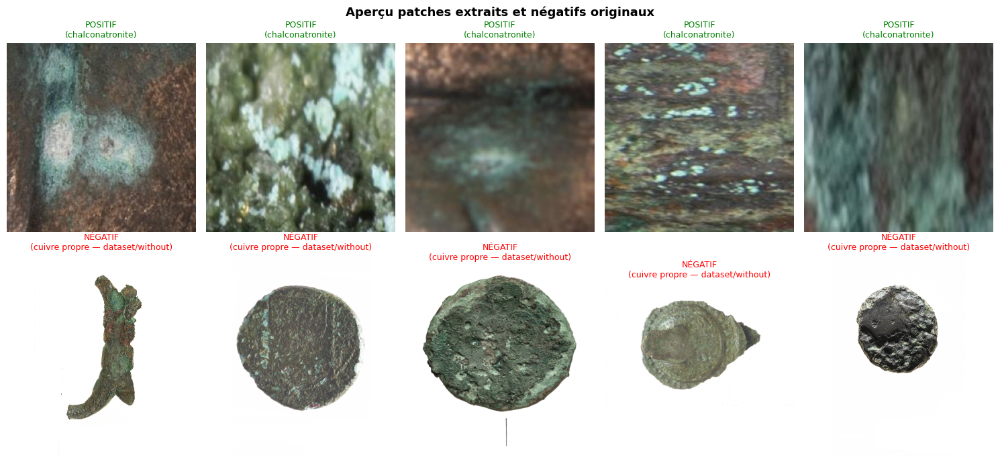

Total positifs dans patches_raw : 4228
  dont patches annotés           : 1928
Total négatifs dans patches_raw  : 1721
  source unique                  : dataset/without_chalconatronite/


In [6]:
def show_patches(pos_dir, neg_dir, n=5):
    """
    Affiche un échantillon de patches positifs (extraits des annotations)
    et de négatifs (copiés depuis dataset/without_chalconatronite/).
    """
    pos_files = [f for f in os.listdir(pos_dir) if 'patch' in f]
    # Négatifs = tous les orig_ (aucun _neg puisque NEG_PER_BOX=0)
    neg_files = [f for f in os.listdir(neg_dir) if f.lower().endswith(('.jpg','.png','.jpeg'))]

    n = min(n, len(pos_files), len(neg_files))
    if n == 0:
        print("Aucun patch/image trouvé.")
        if not pos_files: print(f"  Vérifiez {pos_dir}")
        if not neg_files: print(f"  Vérifiez {neg_dir}")
        return

    random.shuffle(pos_files); random.shuffle(neg_files)

    fig, axes = plt.subplots(2, n, figsize=(3 * n, 7))
    if n == 1:
        axes = axes.reshape(2, 1)
    fig.suptitle("Aperçu patches extraits et négatifs originaux", fontsize=13, fontweight='bold')

    for ax, f in zip(axes[0], pos_files[:n]):
        ax.imshow(Image.open(os.path.join(pos_dir, f)))
        ax.set_title("POSITIF\n(chalconatronite)", color='green', fontsize=9)
        ax.axis("off")

    for ax, f in zip(axes[1], neg_files[:n]):
        ax.imshow(Image.open(os.path.join(neg_dir, f)))
        ax.set_title("NÉGATIF\n(cuivre propre — dataset/without)", color='red', fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Total positifs dans patches_raw : {len(pos_files) + len([f for f in os.listdir(pos_dir) if 'orig_' in f])}")
    print(f"  dont patches annotés           : {len(pos_files)}")
    print(f"Total négatifs dans patches_raw  : {len(neg_files)}")
    print(f"  source unique                  : dataset/without_chalconatronite/")


show_patches(
    os.path.join(PATCHES_RAW_DIR, "with_chalconatronite"),
    os.path.join(PATCHES_RAW_DIR, "without_chalconatronite")
)

## 5 — Split train / val / test

In [7]:
def split_dataset(raw_dir, train_dir, val_dir, test_dir,
                  class_names, val_ratio=0.15, test_ratio=0.10, seed=42):
    """Répartit les images en train/val/test en préservant l'équilibre entre classes."""
    random.seed(seed)
    for cls in class_names:
        src = os.path.join(raw_dir, cls)
        if not os.path.exists(src):
            print(f"Dossier manquant : {src}")
            continue
        files = [f for f in os.listdir(src)
                 if f.lower().endswith(('.jpg', '.png', '.jpeg', '.bmp'))]
        random.shuffle(files)
        n_test = int(len(files) * test_ratio)
        n_val  = int(len(files) * val_ratio)
        splits = {
            test_dir  : files[:n_test],
            val_dir   : files[n_test:n_test + n_val],
            train_dir : files[n_test + n_val:]
        }
        for dest_root, subset in splits.items():
            dest = os.path.join(dest_root, cls)
            os.makedirs(dest, exist_ok=True)
            for fname in subset:
                shutil.copy(os.path.join(src, fname), os.path.join(dest, fname))
        print(f"  {cls}: {len(splits[train_dir])} train | "
              f"{len(splits[val_dir])} val | {len(splits[test_dir])} test")


print("Split dataset :")
split_dataset(
    PATCHES_RAW_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR,
    CLASS_NAMES, VAL_RATIO, TEST_RATIO
)

Split dataset :
  with_chalconatronite: 3172 train | 634 val | 422 test
  without_chalconatronite: 1291 train | 258 val | 172 test


## 6 — Transforms et DataLoaders

In [8]:
# ColorJitter renforcé pour que le modèle ne s'appuie pas sur la couleur seule
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1          # décale légèrement la teinte → bleu/vert ne suffit pas
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN.tolist(), std=STD.tolist())
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN.tolist(), std=STD.tolist())
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = train_dataset.classes
print("Classes :", class_names)
print(f"Train : {len(train_dataset)}  |  Val : {len(val_dataset)}  |  Test : {len(test_dataset)}")

Classes : ['with_chalconatronite', 'without_chalconatronite']
Train : 4463  |  Val : 892  |  Test : 594


## 7 — Modèle EfficientNet-B0

In [9]:
model = models.efficientnet_b0(pretrained=True)

# Phase 1 : features gelées, seul le classifier s'entraîne
for param in model.features.parameters():
    param.requires_grad = False

num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 2)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres entraînables (classifier seul) : {trainable:,}")
print(f"À l'epoch {UNFREEZE_EPOCH}, les features seront dégelées.")

c:\Users\CD44\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\CD44\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Paramètres entraînables (classifier seul) : 2,562
À l'epoch 5, les features seront dégelées.


c:\Users\CD44\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## 8 — Entraînement

In [10]:
history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
best_val_acc = 0

for epoch in range(NUM_EPOCHS):

    # ── Dégel des features à UNFREEZE_EPOCH ────────────────
    if epoch == UNFREEZE_EPOCH:
        for param in model.features.parameters():
            param.requires_grad = True
        optimizer = optim.Adam(model.parameters(), lr=LR / 10)
        print(f" → Epoch {epoch+1} : features dégelées, lr={LR/10:.5f}")

    # ── TRAIN ───────────────────────────────────────────────
    model.train()
    running_loss = correct = total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc  = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    # ── VALIDATION ──────────────────────────────────────────
    model.eval()
    val_loss = val_correct = val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss    += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs, 1)
            val_total   += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc  = 100 * val_correct / val_total
    val_loss = val_loss / len(val_loader)
    scheduler.step(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}]  "
          f"Train: {train_acc:.2f}% / loss {train_loss:.4f}  |  "
          f"Val: {val_acc:.2f}% / loss {val_loss:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_efficientnetb0.pth")
        print("  ✓ Meilleur modèle sauvegardé")

print(f"Meilleure Val Accuracy : {best_val_acc:.2f}%")

Epoch [ 1/15]  Train: 85.70% / loss 0.3453  |  Val: 93.50% / loss 0.2291
  ✓ Meilleur modèle sauvegardé
Epoch [ 2/15]  Train: 89.94% / loss 0.2646  |  Val: 93.61% / loss 0.1960
  ✓ Meilleur modèle sauvegardé
Epoch [ 3/15]  Train: 90.52% / loss 0.2470  |  Val: 93.95% / loss 0.1765
  ✓ Meilleur modèle sauvegardé
Epoch [ 4/15]  Train: 90.79% / loss 0.2380  |  Val: 93.72% / loss 0.1703
Epoch [ 5/15]  Train: 90.77% / loss 0.2402  |  Val: 94.51% / loss 0.1681
  ✓ Meilleur modèle sauvegardé
 → Epoch 6 : features dégelées, lr=0.00010
Epoch [ 6/15]  Train: 93.66% / loss 0.1707  |  Val: 96.41% / loss 0.0989
  ✓ Meilleur modèle sauvegardé
Epoch [ 7/15]  Train: 96.08% / loss 0.1030  |  Val: 97.31% / loss 0.0778
  ✓ Meilleur modèle sauvegardé
Epoch [ 8/15]  Train: 97.38% / loss 0.0756  |  Val: 98.21% / loss 0.0527
  ✓ Meilleur modèle sauvegardé
Epoch [ 9/15]  Train: 98.21% / loss 0.0524  |  Val: 97.53% / loss 0.0631
Epoch [10/15]  Train: 98.45% / loss 0.0466  |  Val: 97.76% / loss 0.0627
Epoch [11/

## 9 — Courbes d'entraînement

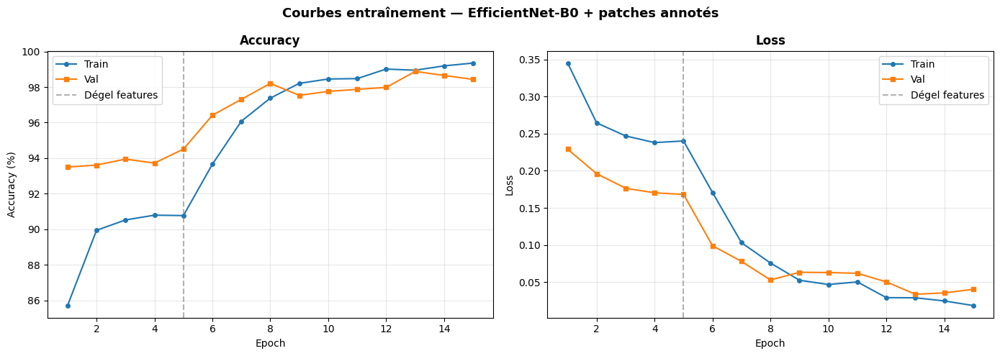

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history['train_acc']) + 1)

ax1.plot(ep, history['train_acc'],  label='Train', marker='o', markersize=4)
ax1.plot(ep, history['val_acc'],    label='Val',   marker='s', markersize=4)
if UNFREEZE_EPOCH < NUM_EPOCHS:
    ax1.axvline(UNFREEZE_EPOCH, color='gray', linestyle='--', alpha=0.6, label='Dégel features')
ax1.set_title('Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy (%)'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, history['train_loss'], label='Train', marker='o', markersize=4)
ax2.plot(ep, history['val_loss'],   label='Val',   marker='s', markersize=4)
if UNFREEZE_EPOCH < NUM_EPOCHS:
    ax2.axvline(UNFREEZE_EPOCH, color='gray', linestyle='--', alpha=0.6, label='Dégel features')
ax2.set_title('Loss', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Courbes entraînement — EfficientNet-B0 + patches annotés', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10 — Évaluation sur le test set

Chargement du meilleur modèle...


C:\Users\CD44\AppData\Local\Temp\ipykernel_29796\114778138.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_efficientnetb0.pth"))


Classification Report:
                         precision    recall  f1-score   support

   with_chalconatronite       0.99      0.99      0.99       422
without_chalconatronite       0.97      0.98      0.97       172

               accuracy                           0.98       594
              macro avg       0.98      0.98      0.98       594
           weighted avg       0.98      0.98      0.98       594

Confusion Matrix:
[[416   6]
 [  4 168]]


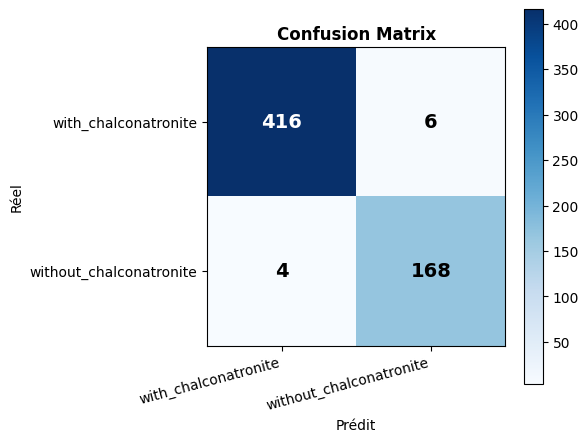

In [12]:
print("Chargement du meilleur modèle...")
model.load_state_dict(torch.load("best_efficientnetb0.pth"))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))
print("Confusion Matrix:")
cm_result = confusion_matrix(all_labels, all_preds)
print(cm_result)

# Visualisation confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_result, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(class_names, rotation=15, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
ax.set_title('Confusion Matrix', fontweight='bold')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_result[i, j]),
                ha='center', va='center',
                color='white' if cm_result[i, j] > cm_result.max() / 2 else 'black',
                fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 11 — Aperçu des prédictions sur le test set

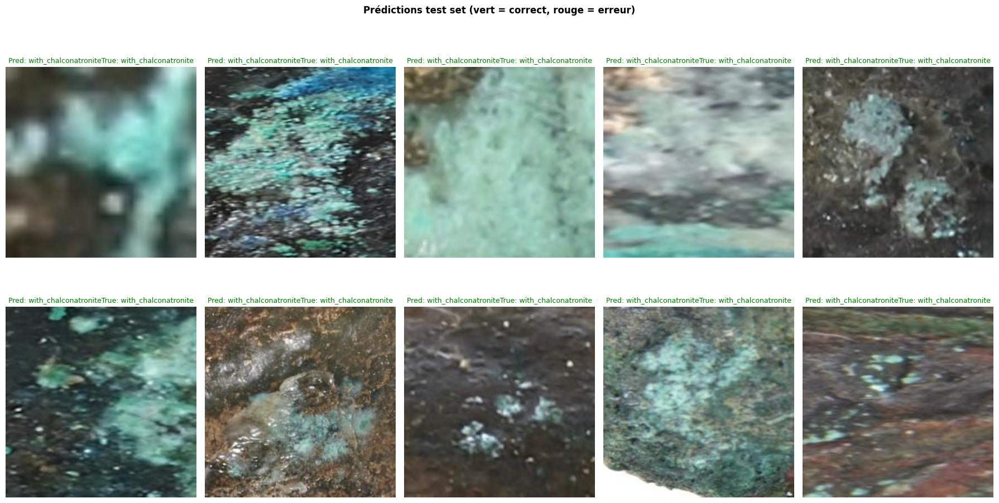

In [13]:
num_images = 10
images_shown = 0

plt.figure(figsize=(18, 10))

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        _, preds = torch.max(outputs, 1)

        for i in range(images.size(0)):
            if images_shown >= num_images:
                break
            img = images[i].permute(1, 2, 0).cpu().numpy()
            img = np.clip(STD * img + MEAN, 0, 1)
            true_lbl = class_names[labels[i]]
            pred_lbl = class_names[preds[i].cpu()]
            color = "green" if true_lbl == pred_lbl else "red"
            plt.subplot(2, 5, images_shown + 1)
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"Pred: {pred_lbl}True: {true_lbl}", color=color, fontsize=9)
            images_shown += 1

        if images_shown >= num_images:
            break

plt.suptitle("Prédictions test set (vert = correct, rouge = erreur)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 12 — Images mal classifiées

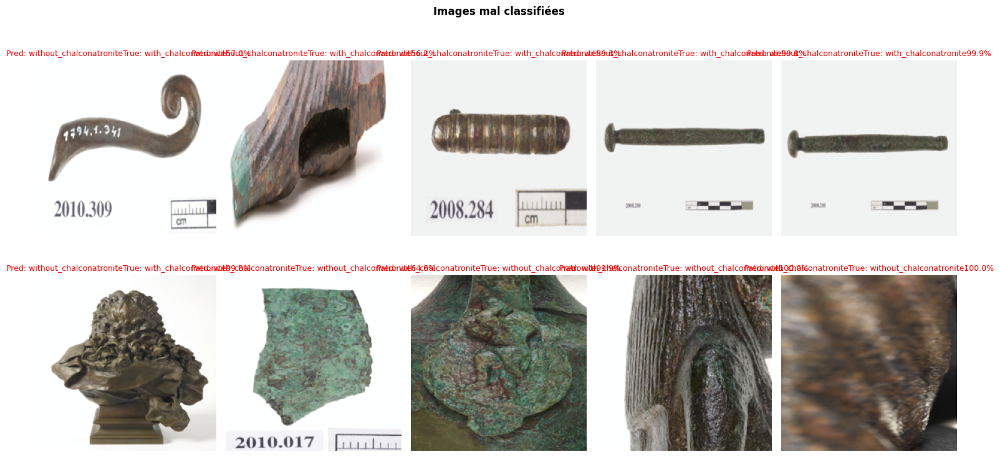

10 erreur(s) affichée(s)


In [14]:
wrong_images = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        probs   = F.softmax(outputs, dim=1)
        _, preds = torch.max(probs, 1)
        for i in range(len(images)):
            if preds[i].cpu() != labels[i]:
                wrong_images.append((
                    images[i],
                    labels[i].item(),
                    preds[i].cpu().item(),
                    probs[i].cpu().numpy()
                ))
        if len(wrong_images) >= 10:
            break

if not wrong_images:
    print("Aucune erreur sur les 10 premières images de test !")
else:
    n = len(wrong_images)
    cols = min(5, n); rows = (n + cols - 1) // cols
    plt.figure(figsize=(15, 4 * rows))
    for i, (img_t, true_lbl, pred_lbl, prob) in enumerate(wrong_images):
        img = np.clip(STD * img_t.permute(1, 2, 0).numpy() + MEAN, 0, 1)
        confidence = prob[pred_lbl] * 100
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"Pred: {class_names[pred_lbl]}True: {class_names[true_lbl]}{confidence:.1f}%",color="red", fontsize=9)
    plt.suptitle("Images mal classifiées", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f"{len(wrong_images)} erreur(s) affichée(s)")

## 13 — Test Grad-CAM sur image externe

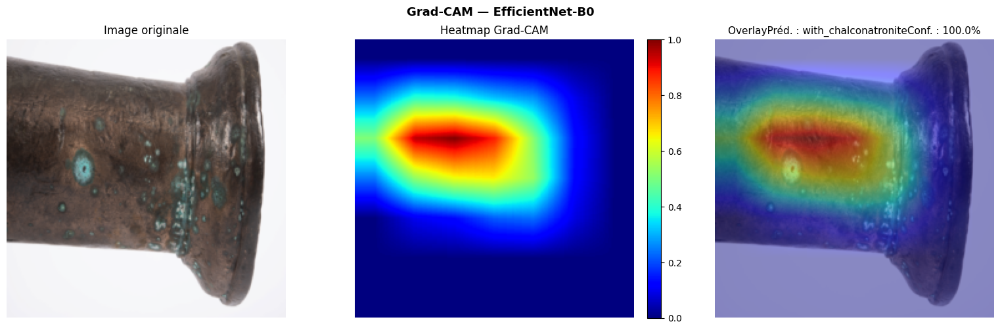

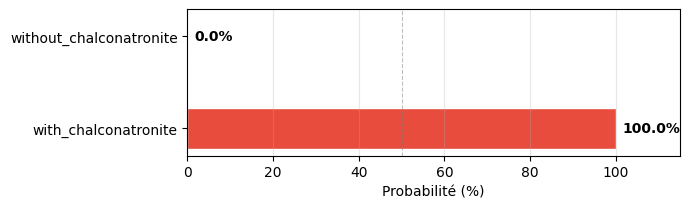

[test-1.jpg]  →  with_chalconatronite  (100.0%)


In [15]:
class GradCAM:
    """Grad-CAM via hooks PyTorch — cible : model.features[-1] (dernière conv, 7×7)."""
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        self._fwd = target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach())
        )
        self._bwd = target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach())
        )

    def generate(self, tensor, class_idx):
        self.model.zero_grad()
        out = self.model(tensor)
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        cam -= cam.min()
        if cam.max() > 0: cam /= cam.max()
        return cam

    def remove(self):
        self._fwd.remove(); self._bwd.remove()


def predict_and_gradcam(image_path, model, true_label=None, save_path=None):
    """Prédiction + Grad-CAM sur une image externe."""
    pil_img = Image.open(image_path).convert("RGB")
    tensor  = val_test_transforms(pil_img).unsqueeze(0).to(device)
    tensor.requires_grad_(True)

    gc = GradCAM(model, model.features[-1])
    with torch.enable_grad():
        out      = model(tensor)
        probs    = F.softmax(out, dim=1).squeeze().detach().cpu().numpy()
        pred_idx = int(np.argmax(probs))
        pred_lbl = class_names[pred_idx]
        cam      = gc.generate(tensor, pred_idx)
    gc.remove()

    # Préparation visuelle
    img_np  = np.clip(STD * tensor.squeeze().permute(1,2,0).detach().cpu().numpy() + MEAN, 0, 1)
    cam_r   = np.array(Image.fromarray((cam*255).astype(np.uint8)).resize(
                  (img_np.shape[1], img_np.shape[0]), Image.BILINEAR)) / 255.0
    overlay = np.clip(0.55 * img_np + 0.45 * cm.jet(cam_r)[:,:,:3], 0, 1)

    # Affichage
    correct = (pred_lbl == true_label) if true_label else None
    color   = "green" if correct else ("red" if correct is False else "black")
    status  = ""
    if true_label:
        status = f"({'✓' if correct else '✗'} {true_label})"

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Grad-CAM — EfficientNet-B0", fontsize=13, fontweight='bold')
    axes[0].imshow(img_np);                                   axes[0].set_title("Image originale");      axes[0].axis("off")
    im = axes[1].imshow(cam_r, cmap='jet', vmin=0, vmax=1);  axes[1].set_title("Heatmap Grad-CAM");    axes[1].axis("off")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    axes[2].imshow(overlay)
    axes[2].set_title(f"OverlayPréd. : {pred_lbl}Conf. : {probs[pred_idx]*100:.1f}%{status}", fontsize=11, color=color);              axes[2].axis("off")
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Sauvegardé : {save_path}")
    plt.show()

    # Barre de probabilités
    fig2, ax = plt.subplots(figsize=(7, 2.2))
    colors_bar = ['#e74c3c', '#2ecc71']
    bars = ax.barh(class_names, probs * 100, color=colors_bar, height=0.45, edgecolor='white')
    ax.set_xlim(0, 115); ax.set_xlabel("Probabilité (%)"); ax.grid(alpha=0.3, axis='x')
    ax.axvline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    for bar, p in zip(bars, probs):
        ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2,
                f"{p*100:.1f}%", va='center', fontsize=10, fontweight='bold')
    plt.tight_layout(); plt.show()

    print(f"[{os.path.basename(image_path)}]  →  {pred_lbl}  ({probs[pred_idx]*100:.1f}%)")
    return {"pred_label": pred_lbl, "probs": probs, "cam": cam}


# ── Test sur une image ─────────────────────────────────────────────────
IMAGE_TEST = "test-1.jpg"   

result = predict_and_gradcam(
    image_path = IMAGE_TEST,
    model      = model,
    true_label = None,               # ex: "with_chalconatronite" ou None
    save_path  = None                # ex: "gradcam_result.png" ou None
)

### On teste encore sur des vrais

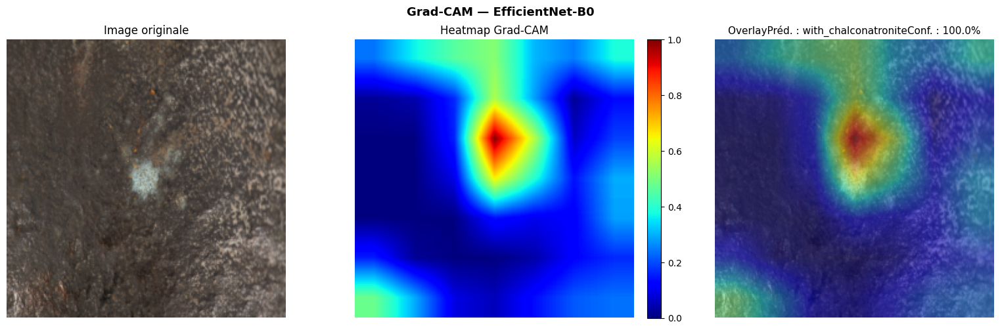

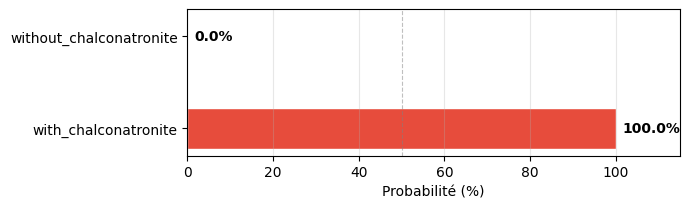

[test-2.jpg]  →  with_chalconatronite  (100.0%)


In [16]:
result = predict_and_gradcam(
    image_path = "test-2.jpg",
    model      = model,
    true_label = None,               # ex: "with_chalconatronite" ou None
    save_path  = None                # ex: "gradcam_result.png" ou None
)

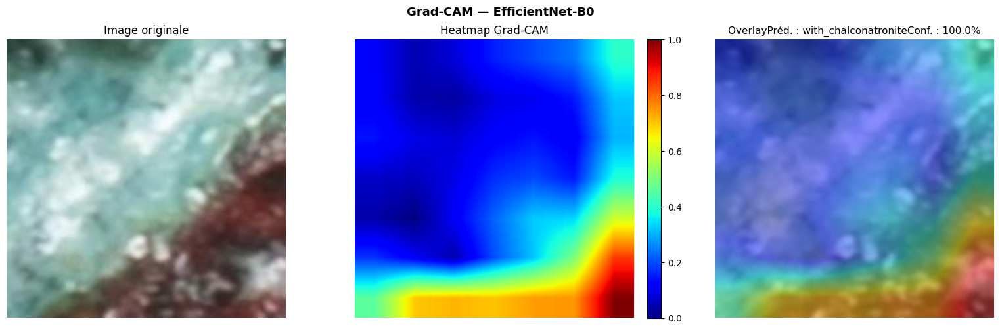

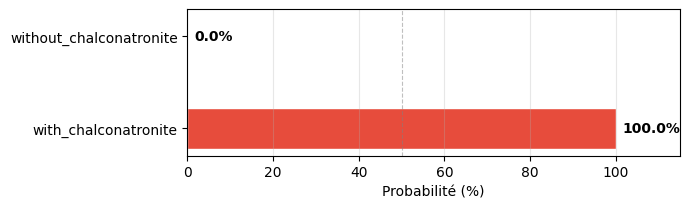

[test-6.jpg]  →  with_chalconatronite  (100.0%)


In [17]:
result = predict_and_gradcam(
    image_path = "test-6.jpg",
    model      = model,
    true_label = None,               # ex: "with_chalconatronite" ou None
    save_path  = None                # ex: "gradcam_result.png" ou None
)

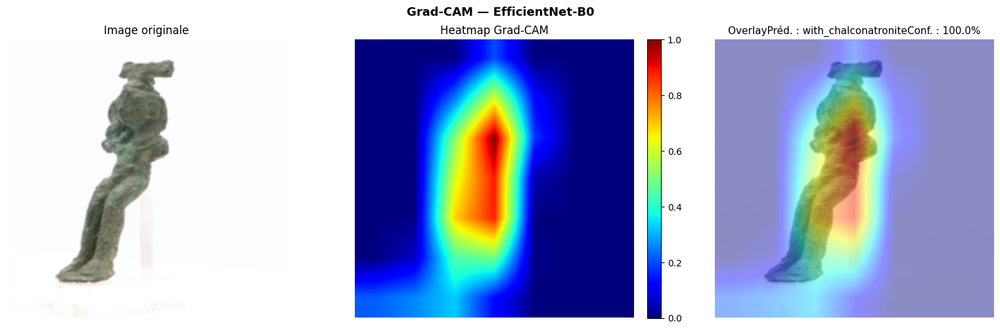

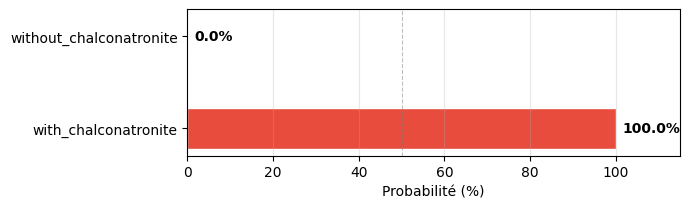

[test-8.png]  →  with_chalconatronite  (100.0%)


In [18]:
result = predict_and_gradcam(
    image_path = "test-8.png",
    model      = model,
    true_label = None,               # ex: "with_chalconatronite" ou None
    save_path  = None                # ex: "gradcam_result.png" ou None
)

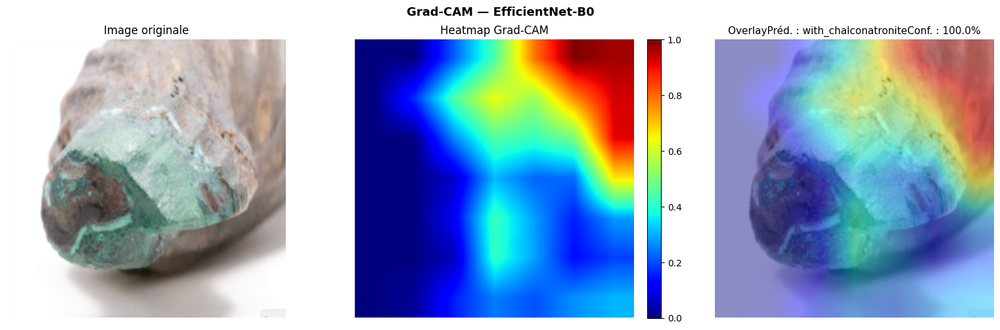

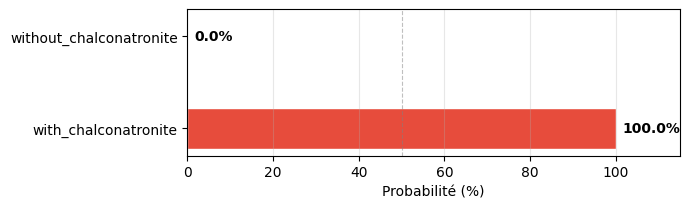

[test-9.png]  →  with_chalconatronite  (100.0%)


In [19]:
result = predict_and_gradcam(
    image_path = "test-9.png",
    model      = model,
    true_label = None,               # ex: "with_chalconatronite" ou None
    save_path  = None                # ex: "gradcam_result.png" ou None
)

### On teste sur des faux

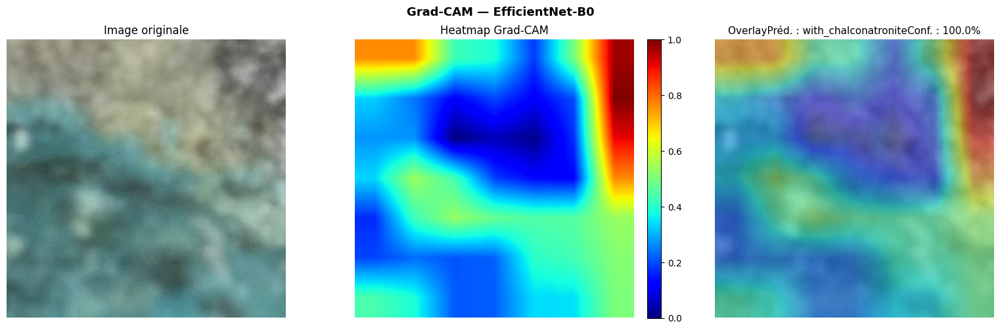

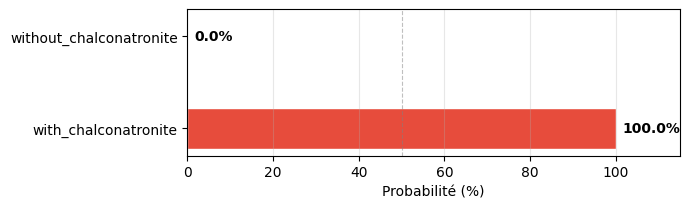

[test-3.jpg]  →  with_chalconatronite  (100.0%)


In [20]:
result = predict_and_gradcam(
    image_path = "test-3.jpg",
    model      = model,
    true_label = None,               # ex: "with_chalconatronite" ou None
    save_path  = None                # ex: "gradcam_result.png" ou None
)

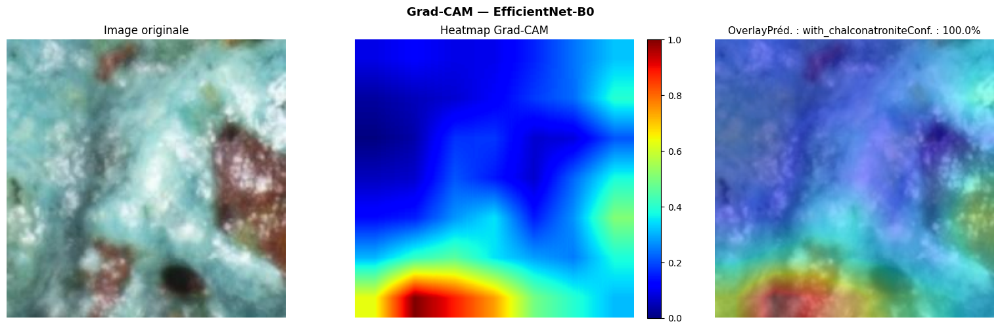

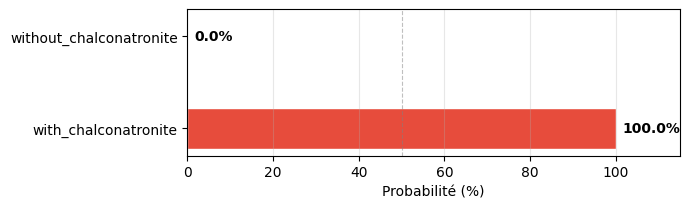

[test-4.jpg]  →  with_chalconatronite  (100.0%)


In [21]:
result = predict_and_gradcam(
    image_path = "test-4.jpg",
    model      = model,
    true_label = None,               # ex: "with_chalconatronite" ou None
    save_path  = None                # ex: "gradcam_result.png" ou None
)

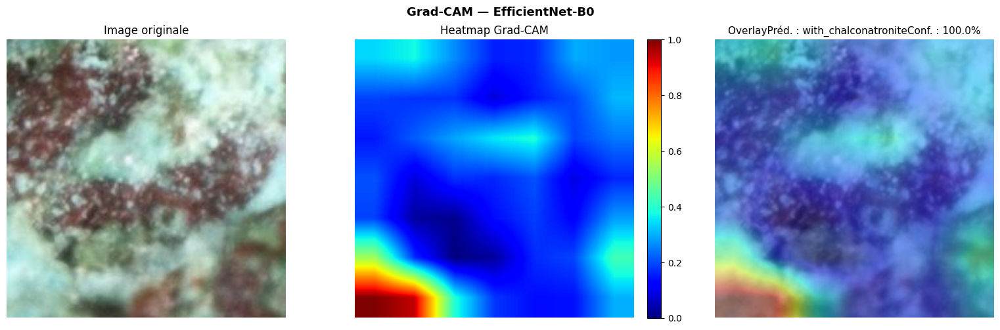

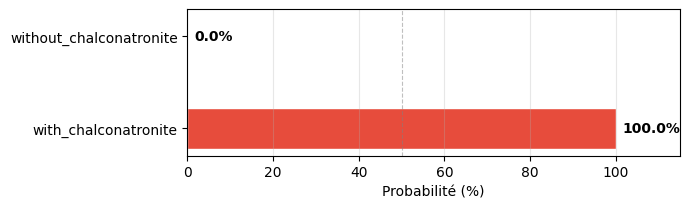

[test-5.jpg]  →  with_chalconatronite  (100.0%)


In [22]:
result = predict_and_gradcam(
    image_path = "test-5.jpg",
    model      = model,
    true_label = None,               # ex: "with_chalconatronite" ou None
    save_path  = None                # ex: "gradcam_result.png" ou None
)

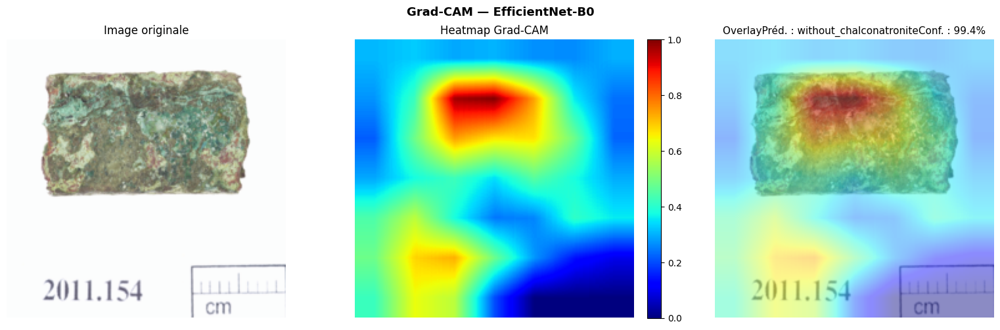

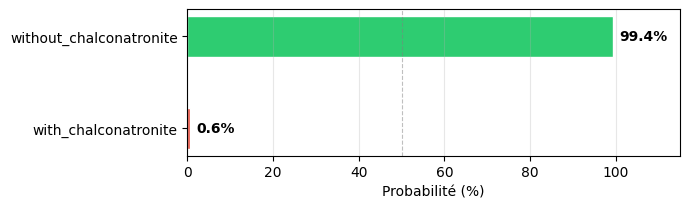

[orig_2011154-102.jpg]  →  without_chalconatronite  (99.4%)


In [23]:
result = predict_and_gradcam(
    image_path = "C:/Users/CD44/Desktop/Nouveau dossier/dataset_split/test/without_chalconatronite/orig_2011154-102.jpg",
    model      = model,
    true_label = None,               # ex: "with_chalconatronite" ou None
    save_path  = None                # ex: "gradcam_result.png" ou None
)

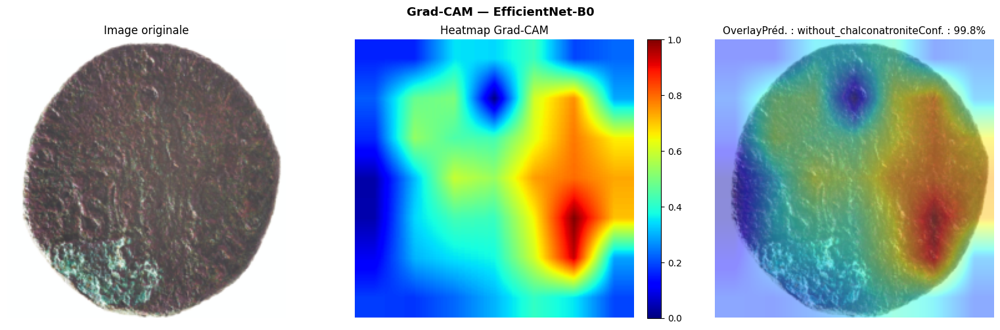

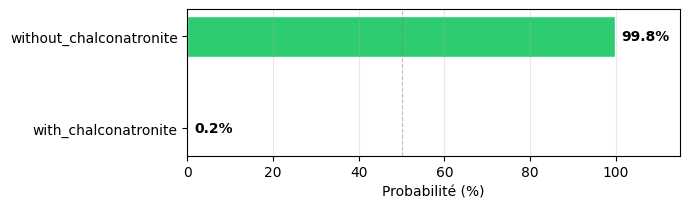

[Capture d'écran 2026-07-28 143425.png]  →  without_chalconatronite  (99.8%)


In [24]:
result = predict_and_gradcam(
    image_path = "C:/Users/CD44/Pictures/Screenshots/Capture d'écran 2026-07-28 143425.png",
    model      = model,
    true_label = None,               # ex: "with_chalconatronite" ou None
    save_path  = None                # ex: "gradcam_result.png" ou None
)

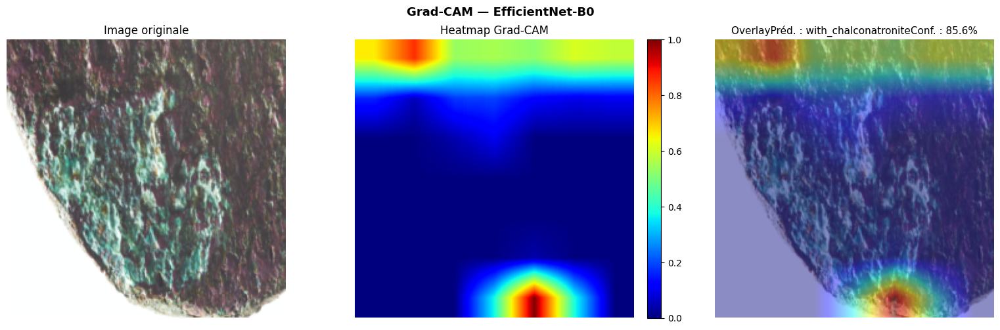

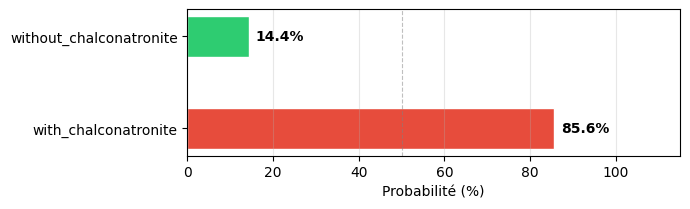

[Capture d'écran 2026-07-28 143534.png]  →  with_chalconatronite  (85.6%)


In [25]:
result = predict_and_gradcam(
    image_path = "C:/Users/CD44/Pictures/Screenshots/Capture d'écran 2026-07-28 143534.png",
    model      = model,
    true_label = None,               # ex: "with_chalconatronite" ou None
    save_path  = None                # ex: "gradcam_result.png" ou None
)

## 14 — Test sur plusieurs images 

In [26]:
# Liste de tuples (chemin_image, vérité_terrain_ou_None, chemin_sauvegarde_ou_None)
images_to_test = [
    ("image1.jpg", "with_chalconatronite",    "out_image1.png"),
    ("image2.jpg", "without_chalconatronite", "out_image2.png"),
    ("image3.jpg", None,                       None),
]

all_results = []
for img_path, true_lbl, save_p in images_to_test:
    if not os.path.exists(img_path):
        print(f"Image introuvable, ignorée : {img_path}")
        continue
    res = predict_and_gradcam(img_path, model, true_lbl, save_p)
    res["image_path"] = img_path
    res["correct"]    = (res["pred_label"] == true_lbl) if true_lbl else None
    all_results.append(res)

# Récapitulatif
if all_results:
    print(f"{'Image':<35} {'Prédiction':<35} {'Conf.':>7}  {'Correct':>7}")
    print("-" * 88)
    for r in all_results:
        name    = os.path.basename(r['image_path'])
        correct = "✓" if r['correct'] else ("✗" if r['correct'] is False else "-")
        print(f"{name:<35} {r['pred_label']:<35} {r['probs'][np.argmax(r['probs'])]*100:>6.1f}%  {correct:>7}")
    labeled = [r for r in all_results if r['correct'] is not None]
    if labeled:
        acc = sum(r['correct'] for r in labeled) / len(labeled) * 100
        print(f"Précision sur {len(labeled)} images labelisées : {acc:.1f}%")

Image introuvable, ignorée : image1.jpg
Image introuvable, ignorée : image2.jpg
Image introuvable, ignorée : image3.jpg
